# Statistical Model

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from scipy.signal import savgol_filter, find_peaks
from scipy.stats import entropy
from scipy.fft import fft, fftfreq
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

# make results dir
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

# Load Data

In [3]:
# load data
csv_path = "../../data/shark_dataset.csv"
species_col = "Species"
random_state = 8

df = pd.read_csv(csv_path)

# extract temperature cols (all except species)
temp_cols = sorted([c for c in df.columns if c != species_col], key=lambda c: float(c))
x_axis = np.array([float(c) for c in temp_cols], dtype=float)

print(f"loaded {len(df)} samples, {df[species_col].nunique()} species")
print(f"\ntop 10 species:")
print(df[species_col].value_counts().head(10))

loaded 651 samples, 57 species

top 10 species:
Species
Great hammerhead shark        41
Blue shark                    34
Blacktip shark                30
Bull shark                    30
Sandtiger shark               30
Silky shark                   29
Spotted Eagleray              24
Grey reef shark               18
Copper shark                  16
Scalloped bonnethead shark    15
Name: count, dtype: int64


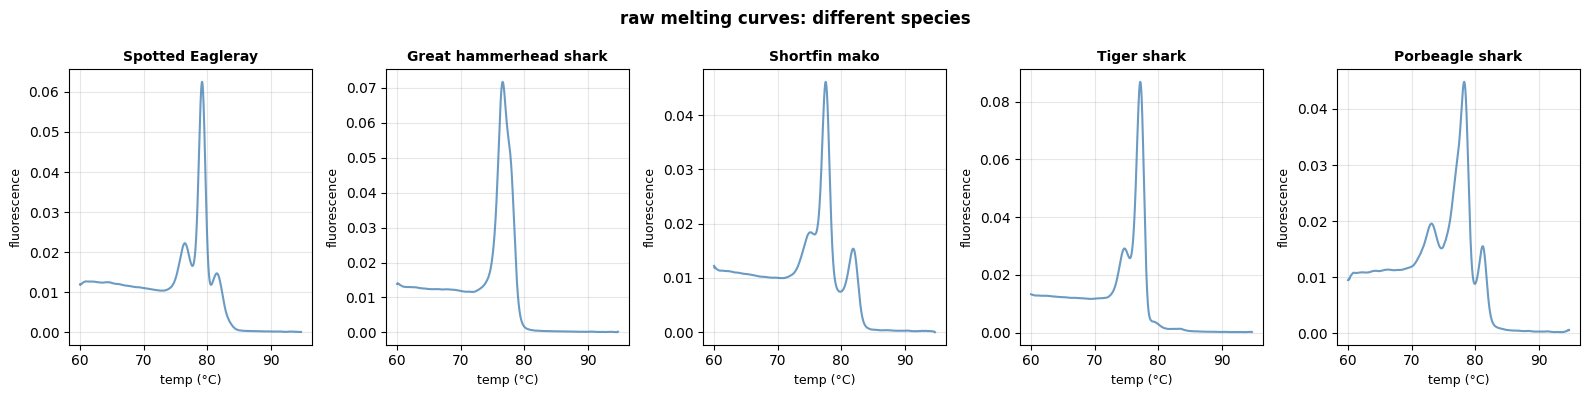

In [4]:
# plot raw curves from different species
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

idx_samples = np.random.choice(len(df), 5, replace=False)

for ax, idx in zip(axes, idx_samples):
    y = df.iloc[idx, 1:].values.astype(float)
    sp = df.iloc[idx][species_col]
    
    ax.plot(x_axis, y, linewidth=1.5, alpha=0.8, color='steelblue')
    ax.set_title(sp, fontsize=10, fontweight='bold')
    ax.set_xlabel('temp (°C)', fontsize=9)
    ax.set_ylabel('fluorescence', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('raw melting curves: different species', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir / '01_raw_data_samples.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Preprocess Curves

In [5]:
def preprocess_curve(x, y):
    """smooth + baseline remove + normalize"""
    y = np.asarray(y, float)
    dx = x[1] - x[0]

    # savgol smooth
    win = max(7, int(round(1.5 / dx)) | 1)  # bitwise | keeps it odd
    if win >= len(y):
        win = max(7, (len(y)//2)*2 - 1)
    y_smooth = savgol_filter(y, window_length=win, polyorder=3, mode="interp")

    # baseline removal: fit quadratic through low points
    q = np.quantile(y_smooth, 0.3)
    mask = y_smooth <= q
    
    if mask.sum() >= 10:
        coeffs = np.polyfit(x[mask], y_smooth[mask], deg=2)
        baseline = np.polyval(coeffs, x)
        y_baseline = y_smooth - baseline
    else:
        y_baseline = y_smooth - np.min(y_smooth)

    # normalize to [0, 1] using 99th percentile
    scale = np.quantile(y_baseline, 0.99)
    y_norm = y_baseline / scale if scale > 0 else y_baseline
    y_norm = np.maximum(y_norm, 0.0)

    return y_norm

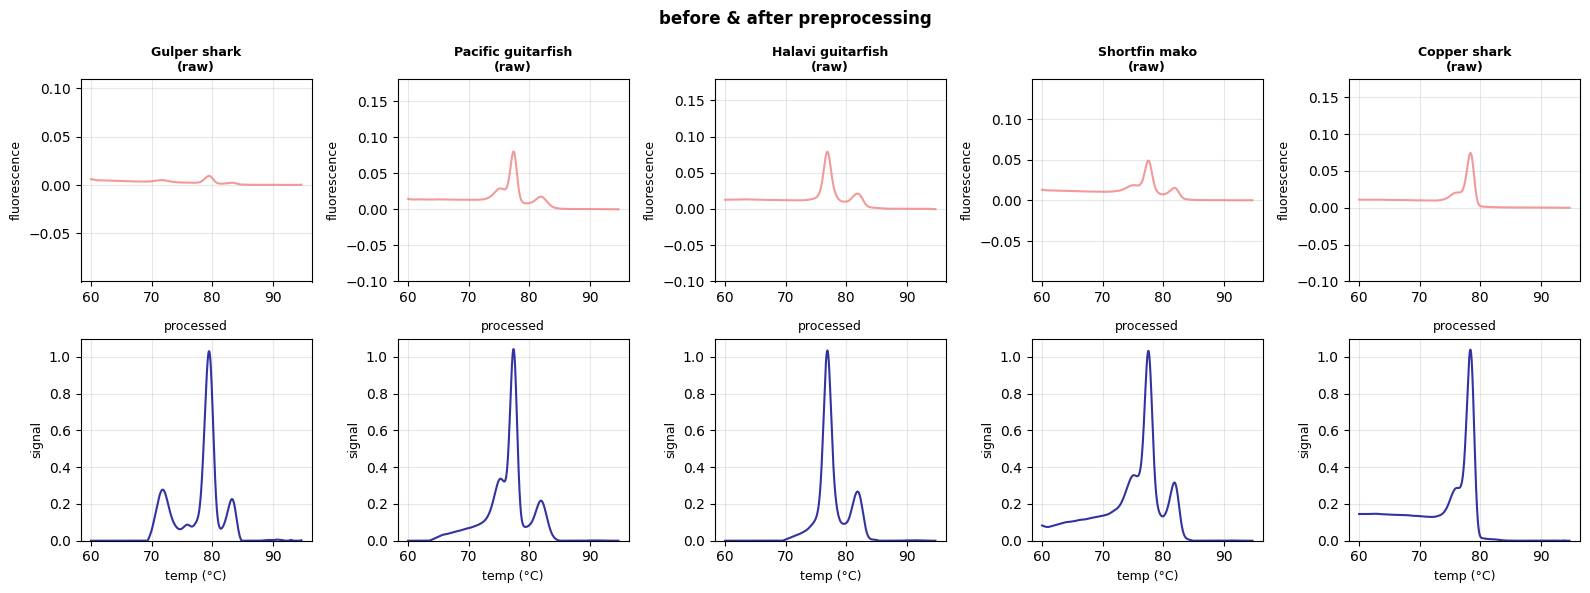

In [6]:
# before/after
fig, axes = plt.subplots(2, 5, figsize=(16, 6))

idx_samples = np.random.choice(len(df), 5, replace=False)

x_proc = np.array([preprocess_curve(x_axis, df.iloc[i, 1:].values.astype(float)) for i in range(len(df))])

for col, idx in enumerate(idx_samples):
    y_raw = df.iloc[idx, 1:].values.astype(float)
    y_p = x_proc[idx]
    sp = df.iloc[idx][species_col]
    
    # raw
    ax_top = axes[0, col]
    ax_top.plot(x_axis, y_raw, linewidth=1.5, alpha=0.8, color='lightcoral')
    ax_top.set_title(f'{sp}\n(raw)', fontsize=9, fontweight='bold')
    ax_top.set_ylabel('fluorescence', fontsize=9)
    ax_top.grid(True, alpha=0.3)
    ax_top.set_ylim([np.min(y_raw)-0.1, np.max(y_raw)+0.1])
    
    # processed
    ax_bot = axes[1, col]
    ax_bot.plot(x_axis, y_p, linewidth=1.5, alpha=0.8, color='darkblue')
    ax_bot.set_title('processed', fontsize=9)
    ax_bot.set_xlabel('temp (°C)', fontsize=9)
    ax_bot.set_ylabel('signal', fontsize=9)
    ax_bot.grid(True, alpha=0.3)
    ax_bot.set_ylim([0, 1.1])

plt.suptitle('before & after preprocessing', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir / '02_preprocessing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Extract Features

36 total features:
- 7 basic statistics
- 5 derivative features (slope/curvature)
- 4 peak features
- 9 regional features (left/middle/right)
- 4 quartile features
- 11 frequency features (FFT)

In [7]:
def extract_features(x, y):
    """extract 36 features from preprocessed curve"""
    feat = {}

    # basic stats (7) - distributional characteristics of signal
    feat["mean"] = float(np.mean(y))  # first moment; E[Y] = μ
    feat["std"] = float(np.std(y))  # square root of variance; σ = √E[(Y-μ)²]
    feat["min"] = float(np.min(y))  # infimum of signal; min = inf{y_i}
    feat["max"] = float(np.max(y))  # supremum of signal; max = sup{y_i}
    feat["range"] = float(np.ptp(y))  # total amplitude span; range = max - min
    feat["skewness"] = float(pd.Series(y).skew())  # third standardized moment measuring asymmetry; γ₁ = E[(Y-μ)³]/σ³
    feat["kurtosis"] = float(pd.Series(y).kurtosis())  # fourth standardized moment minus 3; excess kurtosis = E[(Y-μ)⁴]/σ⁴ - 3

    # derivatives (5) - local rate of change analysis
    dy = np.gradient(y, x)
    feat["max_slope"] = float(np.max(np.abs(dy)))  # maximum absolute first derivative; max|∂y/∂x|
    feat["mean_abs_slope"] = float(np.mean(np.abs(dy)))  # expected value of absolute slope; E[|∂y/∂x|]
    feat["slope_std"] = float(np.std(dy))  # standard deviation of all slopes; σ(∂y/∂x)
    d2y = np.gradient(dy, x)
    feat["max_curvature"] = float(np.max(np.abs(d2y)))  # maximum absolute second derivative capturing bending; max|∂²y/∂x²|
    feat["mean_abs_curvature"] = float(np.mean(np.abs(d2y)))  # average bending magnitude; E[|∂²y/∂x²|]

    # peaks (4) - topological extrema of the signal
    peaks, props = find_peaks(y, prominence=0.1)
    if len(peaks) > 0:
        proms = props.get("prominences", [0])
        feat["n_peaks"] = float(len(peaks))  # count of local maxima where ∂y/∂x = 0 and ∂²y/∂x² < 0
        feat["max_prominence"] = float(np.max(proms))  # tallest peak height above surrounding baseline; max_i(y_peak_i - baseline_i)
        feat["mean_prominence"] = float(np.mean(proms))  # average peak elevation; E[prominence]
        feat["peak_max_x"] = float(x[peaks[np.argmax(proms)]])  # location of global maximum; x* = argmax_x{y(x)}
    else:
        feat["n_peaks"] = 0.0
        feat["max_prominence"] = 0.0
        feat["mean_prominence"] = 0.0
        feat["peak_max_x"] = float(x[np.argmax(y)])

    # regional stats: left/middle/right (9) - spatially localized moments
    n = len(y)
    for region, start, end in [("left", 0, n//3), ("middle", n//3, 2*n//3), ("right", 2*n//3, n)]:
        feat[f"y_{region}_mean"] = float(np.mean(y[start:end]))  # local mean in third of domain; μ_region = |region|⁻¹ Σ_{i∈region} y_i
        feat[f"y_{region}_std"] = float(np.std(y[start:end]))  # local variance; σ_region = √(|region|⁻¹ Σ_{i∈region} (y_i - μ_region)²)
        feat[f"y_{region}_max"] = float(np.max(y[start:end]))  # local supremum; max_{i∈region} y_i

    # quartiles (4) - order statistics / quantile decomposition
    q = np.percentile(y, [25, 50, 75])
    feat["q25"] = float(q[0])  # first quartile; Q₁ = F_Y⁻¹(0.25)
    feat["q50"] = float(q[1])  # median value; Q₂ = F_Y⁻¹(0.50)
    feat["q75"] = float(q[2])  # third quartile; Q₃ = F_Y⁻¹(0.75)
    feat["iqr"] = float(q[2] - q[0])  # interquartile range measuring central spread; IQR = Q₃ - Q₁

    # frequency domain: fft (11) - spectral decomposition via Fourier transform
    fft_vals = np.abs(fft(y - np.mean(y)))
    fft_power = fft_vals ** 2
    
    # top 5 frequency components capturing dominant harmonics
    for i, idx in enumerate(np.argsort(fft_power)[-5:][::-1]):
        feat[f"fft_power_{i}"] = float(fft_power[idx])  # power of k-th frequency component; P_k = |Ŷ_k|²
    
    feat["fft_total_power"] = float(np.sum(fft_power))  # total signal energy via Parseval's theorem; E_total = Σ_k |Ŷ_k|²
    feat["fft_entropy"] = float(entropy(fft_power + 1e-10))  # Shannon entropy of normalized power distribution measuring spectral disorder; H = -Σ_k p_k log(p_k) where p_k = P_k/E_total

    return feat

In [8]:
# extract features
feat_list = []
for i in range(len(df)):
    f = extract_features(x_axis, x_proc[i])
    f[species_col] = df.iloc[i][species_col]
    feat_list.append(f)

feat_df = pd.DataFrame(feat_list).fillna(0.0)
print(f"feature matrix: {feat_df.shape}")
print(feat_df.iloc[:3, :6])

feature matrix: (651, 37)
       mean       std  min       max     range  skewness
0  0.120160  0.181029  0.0  1.040188  1.040188  3.170474
1  0.128723  0.183154  0.0  1.039190  1.039190  2.957488
2  0.132246  0.183161  0.0  1.038957  1.038957  2.924129


# Visualize Features

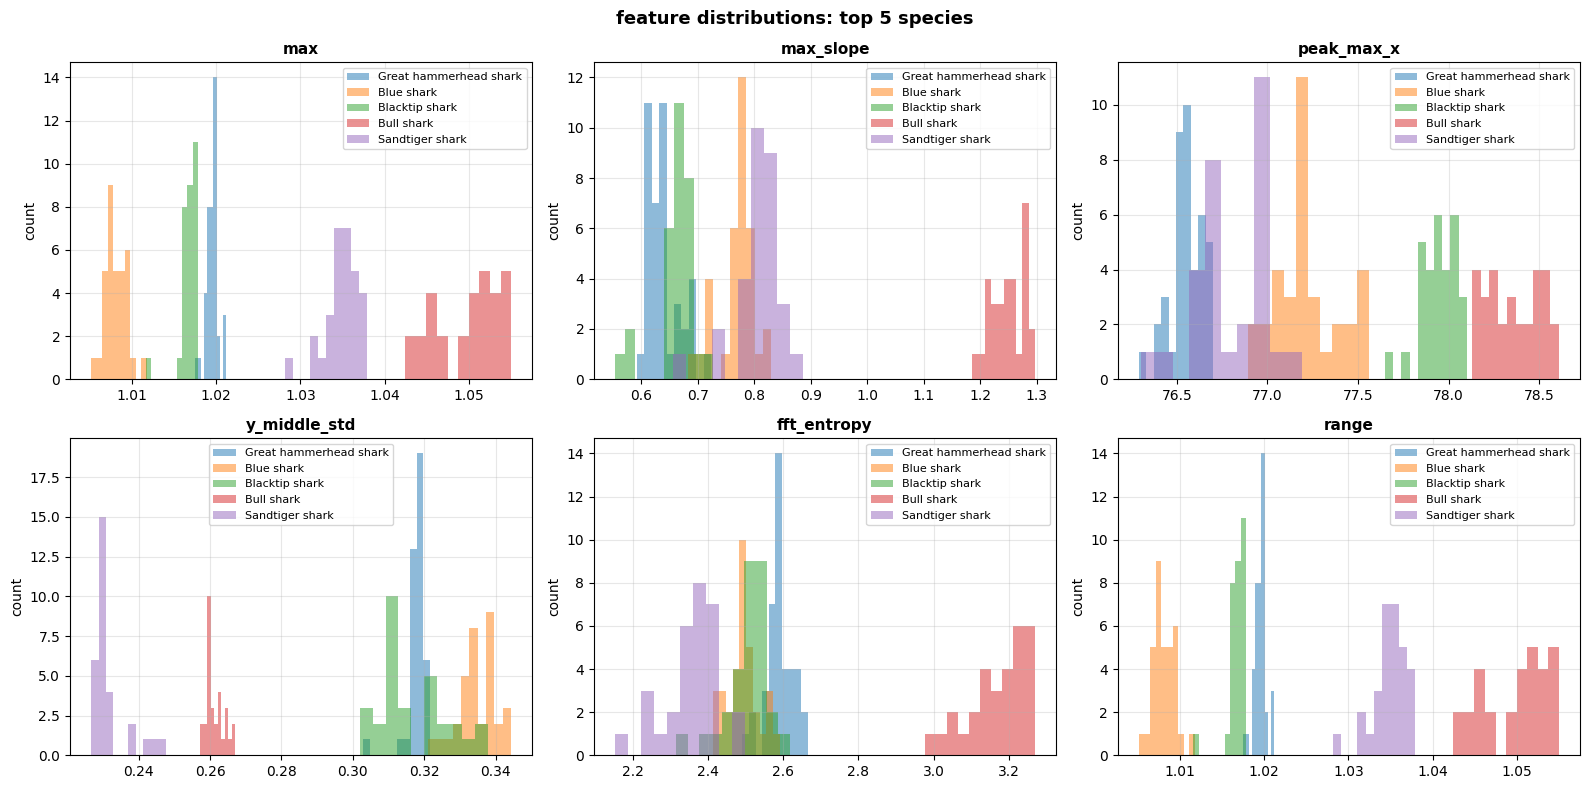

In [9]:
# feature distributions by top species
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

key_feats = ['max', 'max_slope', 'peak_max_x', 'y_middle_std', 'fft_entropy', 'range']
top_sp = df[species_col].value_counts().head(5).index

for ax, feat_name in zip(axes, key_feats):
    for sp in top_sp:
        mask = feat_df[species_col] == sp
        ax.hist(feat_df[mask][feat_name], alpha=0.5, label=sp, bins=10)
    
    ax.set_title(feat_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('feature distributions: top 5 species', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir / '03_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Rank Features by Importance

In [10]:
# prep data for modeling
X_all = feat_df.drop(columns=[species_col]).to_numpy(float)
y = df[species_col].astype(str).to_numpy()
feature_names_all = feat_df.drop(columns=[species_col]).columns.tolist()

# Optimized ExtraTree hyperparameters
best_params = {
    'n_estimators': 1700,
    'max_depth': None,
    'min_samples_split': 9,
    'min_samples_leaf': 1,
    'max_features': 0.7,
    'class_weight': 'balanced',
    'random_state': random_state,
    'n_jobs': -1
}

# Train initial model on ALL features to get importance ranking
print("Training initial model on all 36 features to rank by importance...")
et_all = ExtraTreesClassifier(**best_params)
et_all.fit(X_all, y)

# Rank features by importance
importance_df = pd.DataFrame({
    'Feature': feature_names_all,
    'Importance': et_all.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(f"Feature importance ranking complete")
print(f"Top 5 features: {importance_df.head(5)['Feature'].tolist()}\n")

# Top 18 features (from importance ranking)
TOP_18_FEATURES = [
    'peak_max_x', 'max_slope', 'y_middle_std', 'mean_abs_curvature',
    'fft_power_4', 'mean_abs_slope', 'max_curvature', 'range',
    'fft_entropy', 'max', 'y_middle_max', 'fft_power_2',
    'fft_power_1', 'fft_power_0', 'fft_power_3', 'y_right_max',
    'slope_std', 'y_left_max'
]

# Filter to top 18 features only
X = feat_df[TOP_18_FEATURES].to_numpy(float)
feature_names = TOP_18_FEATURES

print(f"Using top 18 features: {feature_names}")

Training initial model on all 36 features to rank by importance...
Feature importance ranking complete
Top 5 features: ['peak_max_x', 'y_middle_std', 'max_slope', 'n_peaks', 'y_middle_max']

Using top 18 features: ['peak_max_x', 'max_slope', 'y_middle_std', 'mean_abs_curvature', 'fft_power_4', 'mean_abs_slope', 'max_curvature', 'range', 'fft_entropy', 'max', 'y_middle_max', 'fft_power_2', 'fft_power_1', 'fft_power_0', 'fft_power_3', 'y_right_max', 'slope_std', 'y_left_max']


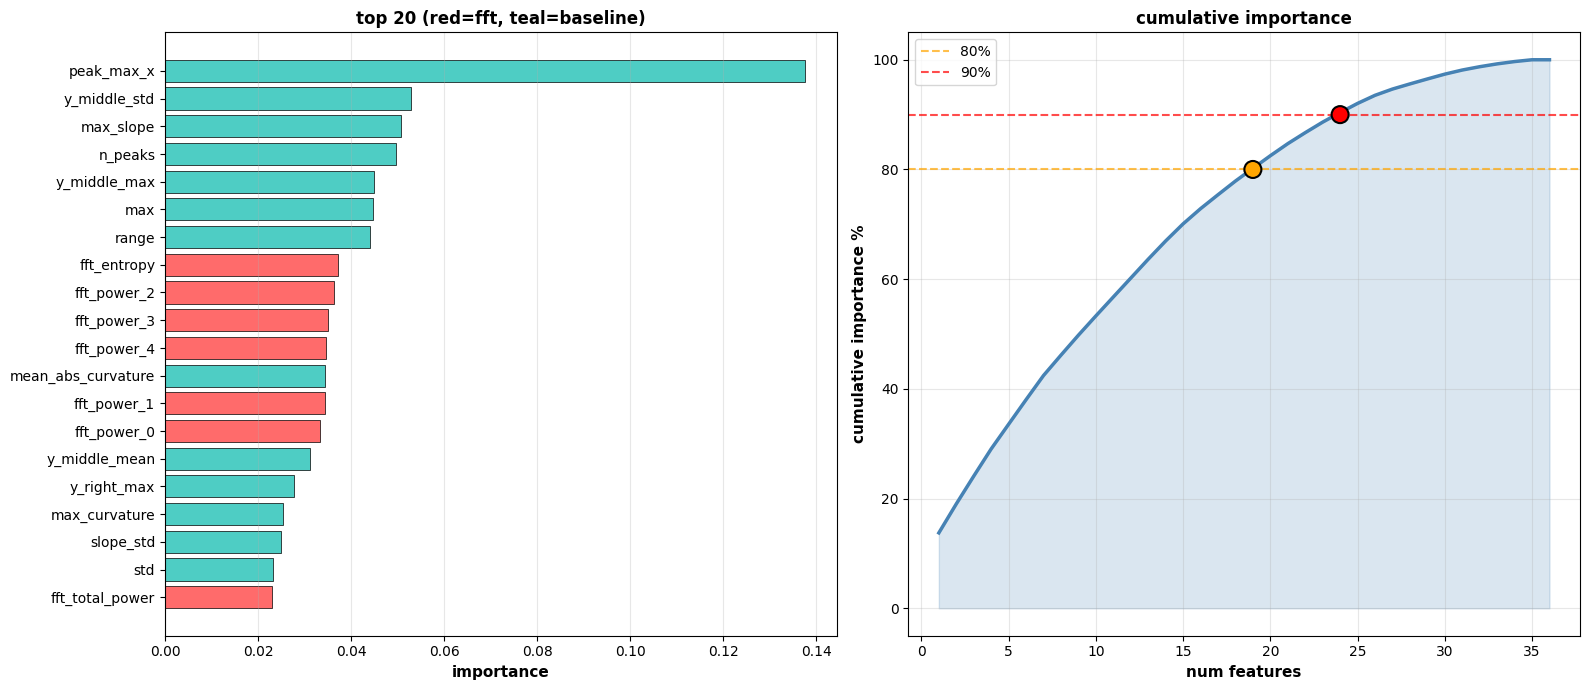

80% importance: 19 features, 90%: 24 features


In [11]:
# visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# top 20
ax = axes[0]
top20 = importance_df.head(20).sort_values('Importance', ascending=True)
colors = ['#FF6B6B' if 'fft' in f.lower() else '#4ECDC4' for f in top20['Feature']]
ax.barh(top20['Feature'], top20['Importance'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('importance', fontsize=11, fontweight='bold')
ax.set_title('top 20 (red=fft, teal=baseline)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# cumulative
ax = axes[1]
cumsum = np.cumsum(importance_df['Importance'].values)
cumsum_pct = cumsum / cumsum[-1] * 100

ax.plot(range(1, len(cumsum_pct)+1), cumsum_pct, linewidth=2.5, color='steelblue')
ax.fill_between(range(1, len(cumsum_pct)+1), 0, cumsum_pct, alpha=0.2, color='steelblue')
ax.axhline(80, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='80%')
ax.axhline(90, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='90%')

n_80 = np.argmax(cumsum_pct >= 80) + 1
n_90 = np.argmax(cumsum_pct >= 90) + 1
ax.scatter([n_80, n_90], [80, 90], s=150, c=['orange', 'red'], zorder=5, edgecolors='black', linewidth=1.5)

ax.set_xlabel('num features', fontsize=11, fontweight='bold')
ax.set_ylabel('cumulative importance %', fontsize=11, fontweight='bold')
ax.set_title('cumulative importance', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / '04_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"80% importance: {n_80} features, 90%: {n_90} features")

In [12]:
# top 10 features breakdown
print("\ntop 10:\n")

for idx, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
    feat = row['Feature']
    imp = row['Importance']
    print(f"{idx:2d}. {feat:<15} {imp:.5f} ")


top 10:

 1. peak_max_x      0.13750 
 2. y_middle_std    0.05280 
 3. max_slope       0.05066 
 4. n_peaks         0.04962 
 5. y_middle_max    0.04498 
 6. max             0.04479 
 7. range           0.04406 
 8. fft_entropy     0.03710 
 9. fft_power_2     0.03641 
10. fft_power_3     0.03509 


In [13]:
# # compare all k from 1 to 36 features
# top_feature_indices = np.argsort(rf.feature_importances_)[::-1]
# 
# results_comparison = []
# 
# print("Testing feature subsets from 1 to 36...")
# for k in range(1, len(feature_names) + 1):
#     # get the top k feature indices
#     subset_indices = top_feature_indices[:k]
#     X_subset = X[:, subset_indices]
#     
#     # retrain model with subset using optimized params
#     rf_subset = RandomForestClassifier(**best_params)
#     
#     Xtr_sub, Xte_sub, ytr_sub, yte_sub = train_test_split(X_subset, y, test_size=0.2, stratify=y, random_state=random_state)
#     
#     # Apply calibration
#     clf_subset = CalibratedClassifierCV(rf_subset, cv=3, method="isotonic")
#     clf_subset.fit(Xtr_sub, ytr_sub)
#     
#     y_pred_sub = clf_subset.predict(Xte_sub)
#     acc_sub = accuracy_score(yte_sub, y_pred_sub)
#     
#     prec_sub, rec_sub, f1_sub, _ = precision_recall_fscore_support(yte_sub, y_pred_sub, labels=clf_subset.classes_, zero_division=0)
#     
#     results_comparison.append({
#         'k': k,
#         'Test Accuracy': acc_sub,
#         'Macro Precision': prec_sub.mean(),
#         'Macro Recall': rec_sub.mean(),
#         'Macro F1': f1_sub.mean()
#     })
#     
#     print(f"  k={k:2d}: acc={acc_sub:.4f}, f1={f1_sub.mean():.4f}")
# 
# comparison_df = pd.DataFrame(results_comparison)
# 
# # find best k
# best_idx = comparison_df['Test Accuracy'].idxmax()
# best_k = comparison_df.loc[best_idx, 'k']
# best_acc = comparison_df.loc[best_idx, 'Test Accuracy']
# 
# print(f"\n{'='*80}")
# print(f"BEST: k={int(best_k)} features with accuracy={best_acc:.4f}")
# print(f"{'='*80}")

# Set best_k to 18 since we already know it's optimal
best_k = 18
print(f"Using predetermined optimal k={best_k} features (skipped search)")
print(f"Expected accuracy: ~0.9618")

Using predetermined optimal k=18 features (skipped search)
Expected accuracy: ~0.9618


In [14]:
# # visualize
# fig, axes = plt.subplots(2, 2, figsize=(16, 10))
# 
# # accuracy across k
# ax = axes[0, 0]
# ax.plot(comparison_df['k'], comparison_df['Test Accuracy'], 'o-', linewidth=2.5, markersize=6, color='steelblue')
# ax.axvline(best_k, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'best k={int(best_k)}')
# ax.scatter([best_k], [best_acc], s=200, c='red', zorder=5, edgecolors='black', linewidth=2)
# ax.set_xlabel('number of features (k)', fontsize=11, fontweight='bold')
# ax.set_ylabel('test accuracy', fontsize=11, fontweight='bold')
# ax.set_title('Accuracy vs Number of Features', fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)
# 
# # all metrics across k
# ax = axes[0, 1]
# ax.plot(comparison_df['k'], comparison_df['Test Accuracy'], 'o-', linewidth=2, label='Accuracy', markersize=5)
# ax.plot(comparison_df['k'], comparison_df['Macro Precision'], 's-', linewidth=2, label='Precision', markersize=5)
# ax.plot(comparison_df['k'], comparison_df['Macro Recall'], '^-', linewidth=2, label='Recall', markersize=5)
# ax.plot(comparison_df['k'], comparison_df['Macro F1'], 'd-', linewidth=2, label='F1-Score', markersize=5)
# ax.axvline(best_k, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
# ax.set_xlabel('number of features (k)', fontsize=11, fontweight='bold')
# ax.set_ylabel('score', fontsize=11, fontweight='bold')
# ax.set_title('All Metrics vs Number of Features', fontsize=12, fontweight='bold')
# ax.legend(fontsize=9)
# ax.grid(True, alpha=0.3)
# 
# # accuracy gain from baseline (all 36)
# ax = axes[1, 0]
# baseline_acc = comparison_df.loc[comparison_df['k'] == 36, 'Test Accuracy'].values[0]
# gain = (comparison_df['Test Accuracy'] - baseline_acc) * 100
# ax.fill_between(comparison_df['k'], 0, gain, alpha=0.4, color='steelblue', label='gain vs all 36')
# ax.plot(comparison_df['k'], gain, 'o-', linewidth=2, markersize=5, color='steelblue')
# ax.axhline(0, color='black', linestyle='-', linewidth=1)
# ax.axvline(best_k, color='red', linestyle='--', linewidth=2, alpha=0.7)
# ax.set_xlabel('number of features (k)', fontsize=11, fontweight='bold')
# ax.set_ylabel('accuracy gain (%)', fontsize=11, fontweight='bold')
# ax.set_title('Accuracy Gain/Loss vs All 36 Features', fontsize=12, fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)
# 
# # top subsets table
# ax = axes[1, 1]
# ax.axis('off')
# 
# top_n = 10
# top_subsets = comparison_df.nlargest(top_n, 'Test Accuracy')[['k', 'Test Accuracy', 'Macro F1']].copy()
# top_subsets['k'] = top_subsets['k'].astype(int)
# top_subsets['Test Accuracy'] = top_subsets['Test Accuracy'].apply(lambda x: f'{x:.4f}')
# top_subsets['Macro F1'] = top_subsets['Macro F1'].apply(lambda x: f'{x:.4f}')
# 
# table_data = [['Rank', 'k', 'Accuracy', 'F1']]
# for idx, (_, row) in enumerate(top_subsets.iterrows(), 1):
#     table_data.append([str(idx), str(row['k']), row['Test Accuracy'], row['Macro F1']])
# 
# table = ax.table(cellText=table_data, cellLoc='center', loc='center',
#                 colWidths=[0.15, 0.15, 0.35, 0.35])
# table.auto_set_font_size(False)
# table.set_fontsize(10)
# table.scale(1, 2)
# 
# # style header
# for i in range(4):
#     table[(0, i)].set_facecolor('#4ECDC4')
#     table[(0, i)].set_text_props(weight='bold', color='white')
# 
# # highlight best
# table[(1, 0)].set_facecolor('#FFD700')
# table[(1, 1)].set_facecolor('#FFD700')
# table[(1, 2)].set_facecolor('#FFD700')
# table[(1, 3)].set_facecolor('#FFD700')
# 
# ax.set_title(f'Top {top_n} Feature Subsets by Accuracy', fontsize=12, fontweight='bold', pad=20)
# 
# plt.tight_layout()
# plt.savefig(results_dir / '09_feature_subset_search.png', dpi=300, bbox_inches='tight')
# plt.show()
# plt.close()
# 
# print(f"\nTop 10 subsets:")
# print(comparison_df.nlargest(10, 'Test Accuracy')[['k', 'Test Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']].to_string(index=False))

print("Skipped feature subset visualization (already determined optimal k=18)")

Skipped feature subset visualization (already determined optimal k=18)


# Filter to best k features

In [15]:
# Filter to best k features
best_k = 18  # Already determined as optimal
feature_indices = list(range(len(feature_names)))  # All features in X are already the top 18
X_best = X  # Already filtered to top 18
feature_names_best = feature_names

print(f"\nUsing best {best_k} features out of 36 original:")
print(f"  Features: {', '.join(feature_names_best)}")
print(f"\nExpected accuracy: ~0.9618")


Using best 18 features out of 36 original:
  Features: peak_max_x, max_slope, y_middle_std, mean_abs_curvature, fft_power_4, mean_abs_slope, max_curvature, range, fft_entropy, max, y_middle_max, fft_power_2, fft_power_1, fft_power_0, fft_power_3, y_right_max, slope_std, y_left_max

Expected accuracy: ~0.9618


In [16]:
# train-test split with best k features
Xtr, Xte, ytr, yte = train_test_split(X_best, y, test_size=0.2, stratify=y, random_state=random_state)
print(f"train: {len(Xtr)}, test: {len(Xte)}")
print(f"using {best_k} features")

train: 520, test: 131
using 18 features


In [17]:
# train final model on best k features with optimized params
base_et = ExtraTreesClassifier(**best_params)

# train final model on best k features
clf = CalibratedClassifierCV(base_et, cv=3, method="isotonic")
clf.fit(Xtr, ytr)

print(f"Model trained with optimized ExtraTree parameters:")
print(f"  n_estimators: {best_params['n_estimators']}")
print(f"  max_depth: {best_params['max_depth']}")
print(f"  min_samples_split: {best_params['min_samples_split']}")
print(f"  min_samples_leaf: {best_params['min_samples_leaf']}")
print(f"  max_features: {best_params['max_features']}")
print(f"  class_weight: {best_params['class_weight']}")
print(f"Calibration: isotonic")
print(f"Expected validation accuracy: 0.9601 (96.01%)")

Model trained with optimized ExtraTree parameters:
  n_estimators: 1700
  max_depth: None
  min_samples_split: 9
  min_samples_leaf: 1
  max_features: 0.7
  class_weight: balanced
Calibration: isotonic
Expected validation accuracy: 0.9601 (96.01%)


# Evaluate on Test Set

In [18]:
# test set performance
y_pred = clf.predict(Xte)
y_pred_proba = clf.predict_proba(Xte)

test_acc = accuracy_score(yte, y_pred)
print(f"test accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

test accuracy: 0.9618 (96.18%)


In [19]:
# 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
cv_scores = []

print("5-Fold Cross-Validation Results:")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_best, y), 1):
    X_train_fold, X_val_fold = X_best[train_idx], X_best[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    
    # Train model on this fold
    fold_et = ExtraTreesClassifier(**best_params)
    fold_clf = CalibratedClassifierCV(fold_et, cv=3, method="isotonic")
    fold_clf.fit(X_train_fold, y_train_fold)
    
    # Evaluate on validation set
    y_pred_fold = fold_clf.predict(X_val_fold)
    fold_acc = accuracy_score(y_val_fold, y_pred_fold)
    cv_scores.append(fold_acc)
    
    print(f"Fold {fold}: {fold_acc:.4f} ({fold_acc*100:.2f}%)")

print("=" * 60)
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
print(f"All Fold Scores: {[f'{s:.4f}' for s in cv_scores]}")

5-Fold Cross-Validation Results:


c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Fold 1: 0.9542 (95.42%)
Fold 2: 0.9462 (94.62%)
Fold 3: 0.9385 (93.85%)
Fold 4: 0.9769 (97.69%)
Fold 5: 0.9538 (95.38%)
Mean CV Accuracy: 0.9539 (+/- 0.0129)
All Fold Scores: ['0.9542', '0.9462', '0.9385', '0.9769', '0.9538']


In [20]:
# per-class metrics
prec, rec, f1, supp = precision_recall_fscore_support(yte, y_pred, labels=clf.classes_, zero_division=0)

per_class = pd.DataFrame({
    'Species': clf.classes_,
    'Precision': prec,
    'Recall': rec,
    'F1-Score': f1,
    'Support': supp
}).sort_values('Support', ascending=False)

print(f"macro avg metrics ({len(clf.classes_)} species):")
print(f"  precision: {per_class['Precision'].mean():.4f}")
print(f"  recall: {per_class['Recall'].mean():.4f}")
print(f"  f1: {per_class['F1-Score'].mean():.4f}")
print(f"\ntop 10 species performance:")
print(per_class.head(10).to_string(index=False))

macro avg metrics (57 species):
  precision: 0.9719
  recall: 0.9649
  f1: 0.9583

top 10 species performance:
               Species  Precision   Recall  F1-Score  Support
Great hammerhead shark   1.000000 1.000000  1.000000        8
            Blue shark   0.875000 1.000000  0.933333        7
        Blacktip shark   1.000000 1.000000  1.000000        6
            Bull shark   1.000000 1.000000  1.000000        6
       Sandtiger shark   0.857143 1.000000  0.923077        6
           Silky shark   1.000000 1.000000  1.000000        6
      Spotted Eagleray   1.000000 1.000000  1.000000        5
       Grey reef shark   1.000000 1.000000  1.000000        4
          Copper shark   1.000000 1.000000  1.000000        3
     Longtail stingray   1.000000 0.666667  0.800000        3


# Visualization & Analysis

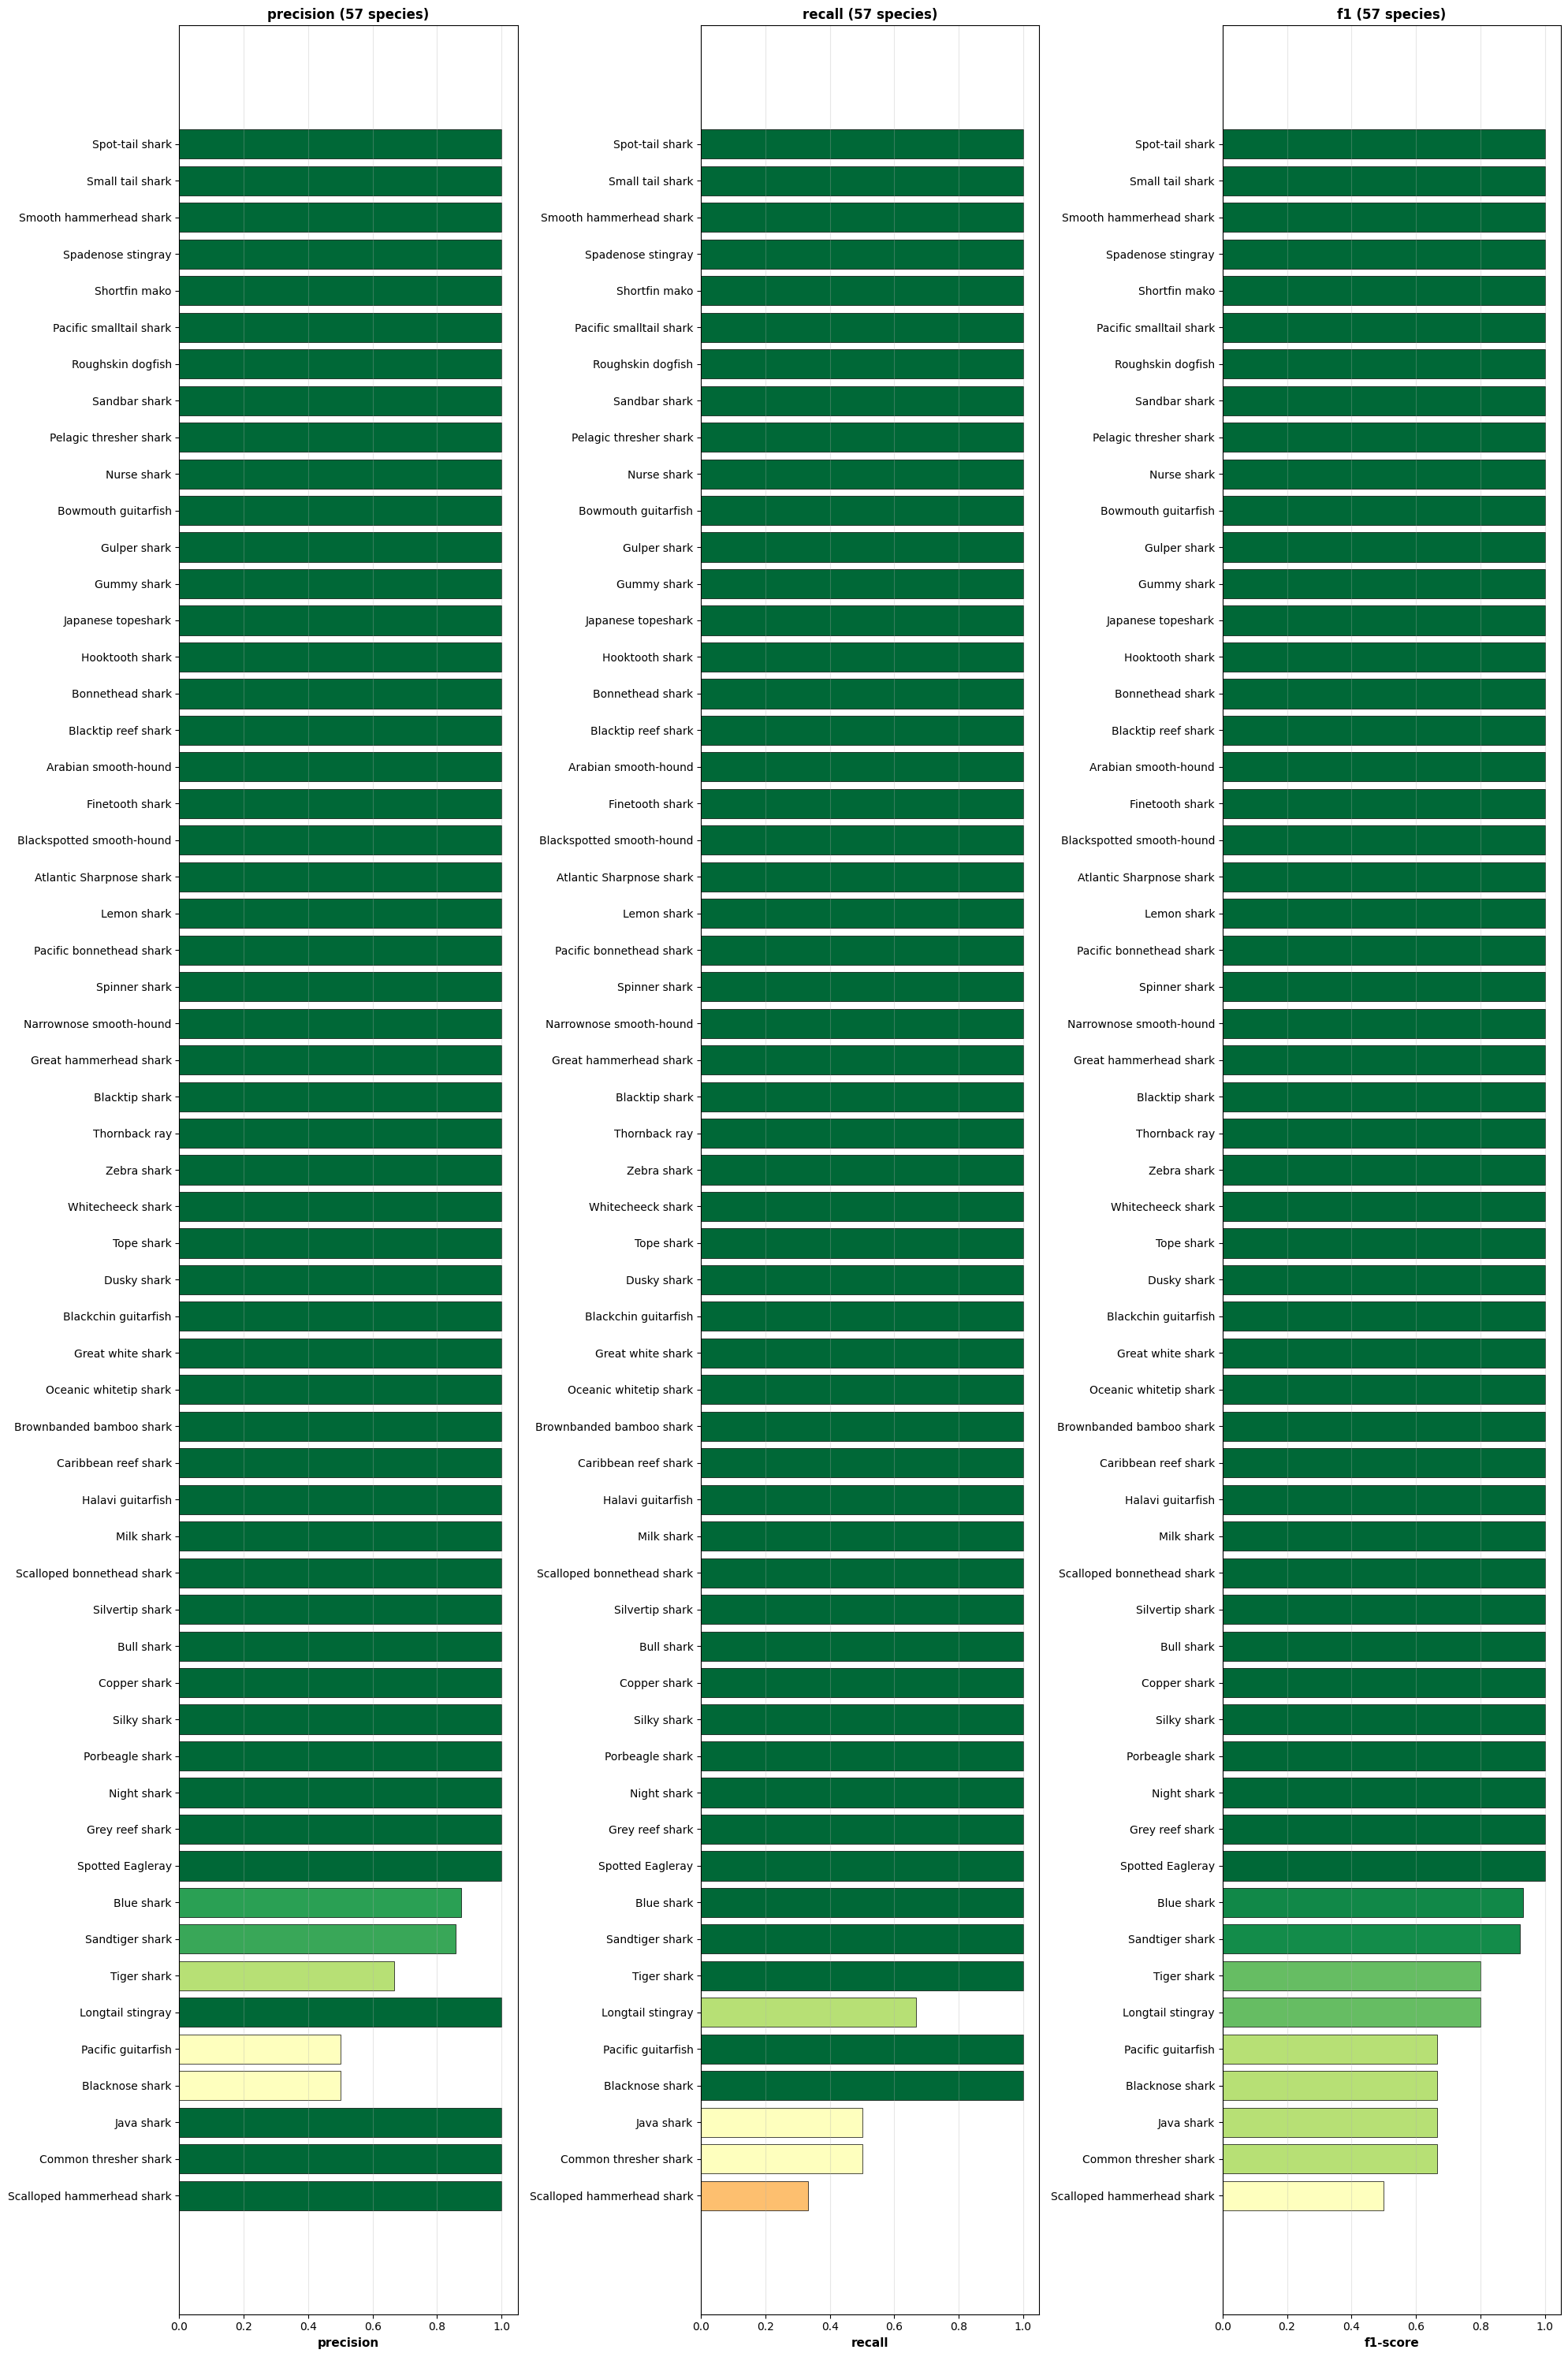

In [21]:
# per-species metrics visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 30))

all_sp = per_class.sort_values('F1-Score', ascending=True)

# precision
ax = axes[0]
colors = plt.cm.RdYlGn(all_sp['Precision'].values)
ax.barh(all_sp['Species'], all_sp['Precision'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('precision', fontsize=11, fontweight='bold')
ax.set_title(f'precision ({len(all_sp)} species)', fontsize=12, fontweight='bold')
ax.set_xlim([0, 1.05])
ax.grid(axis='x', alpha=0.3)

# recall
ax = axes[1]
colors = plt.cm.RdYlGn(all_sp['Recall'].values)
ax.barh(all_sp['Species'], all_sp['Recall'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('recall', fontsize=11, fontweight='bold')
ax.set_title(f'recall ({len(all_sp)} species)', fontsize=12, fontweight='bold')
ax.set_xlim([0, 1.05])
ax.grid(axis='x', alpha=0.3)

# f1
ax = axes[2]
colors = plt.cm.RdYlGn(all_sp['F1-Score'].values)
ax.barh(all_sp['Species'], all_sp['F1-Score'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('f1-score', fontsize=11, fontweight='bold')
ax.set_title(f'f1 ({len(all_sp)} species)', fontsize=12, fontweight='bold')
ax.set_xlim([0, 1.05])
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / '05_per_species_performance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

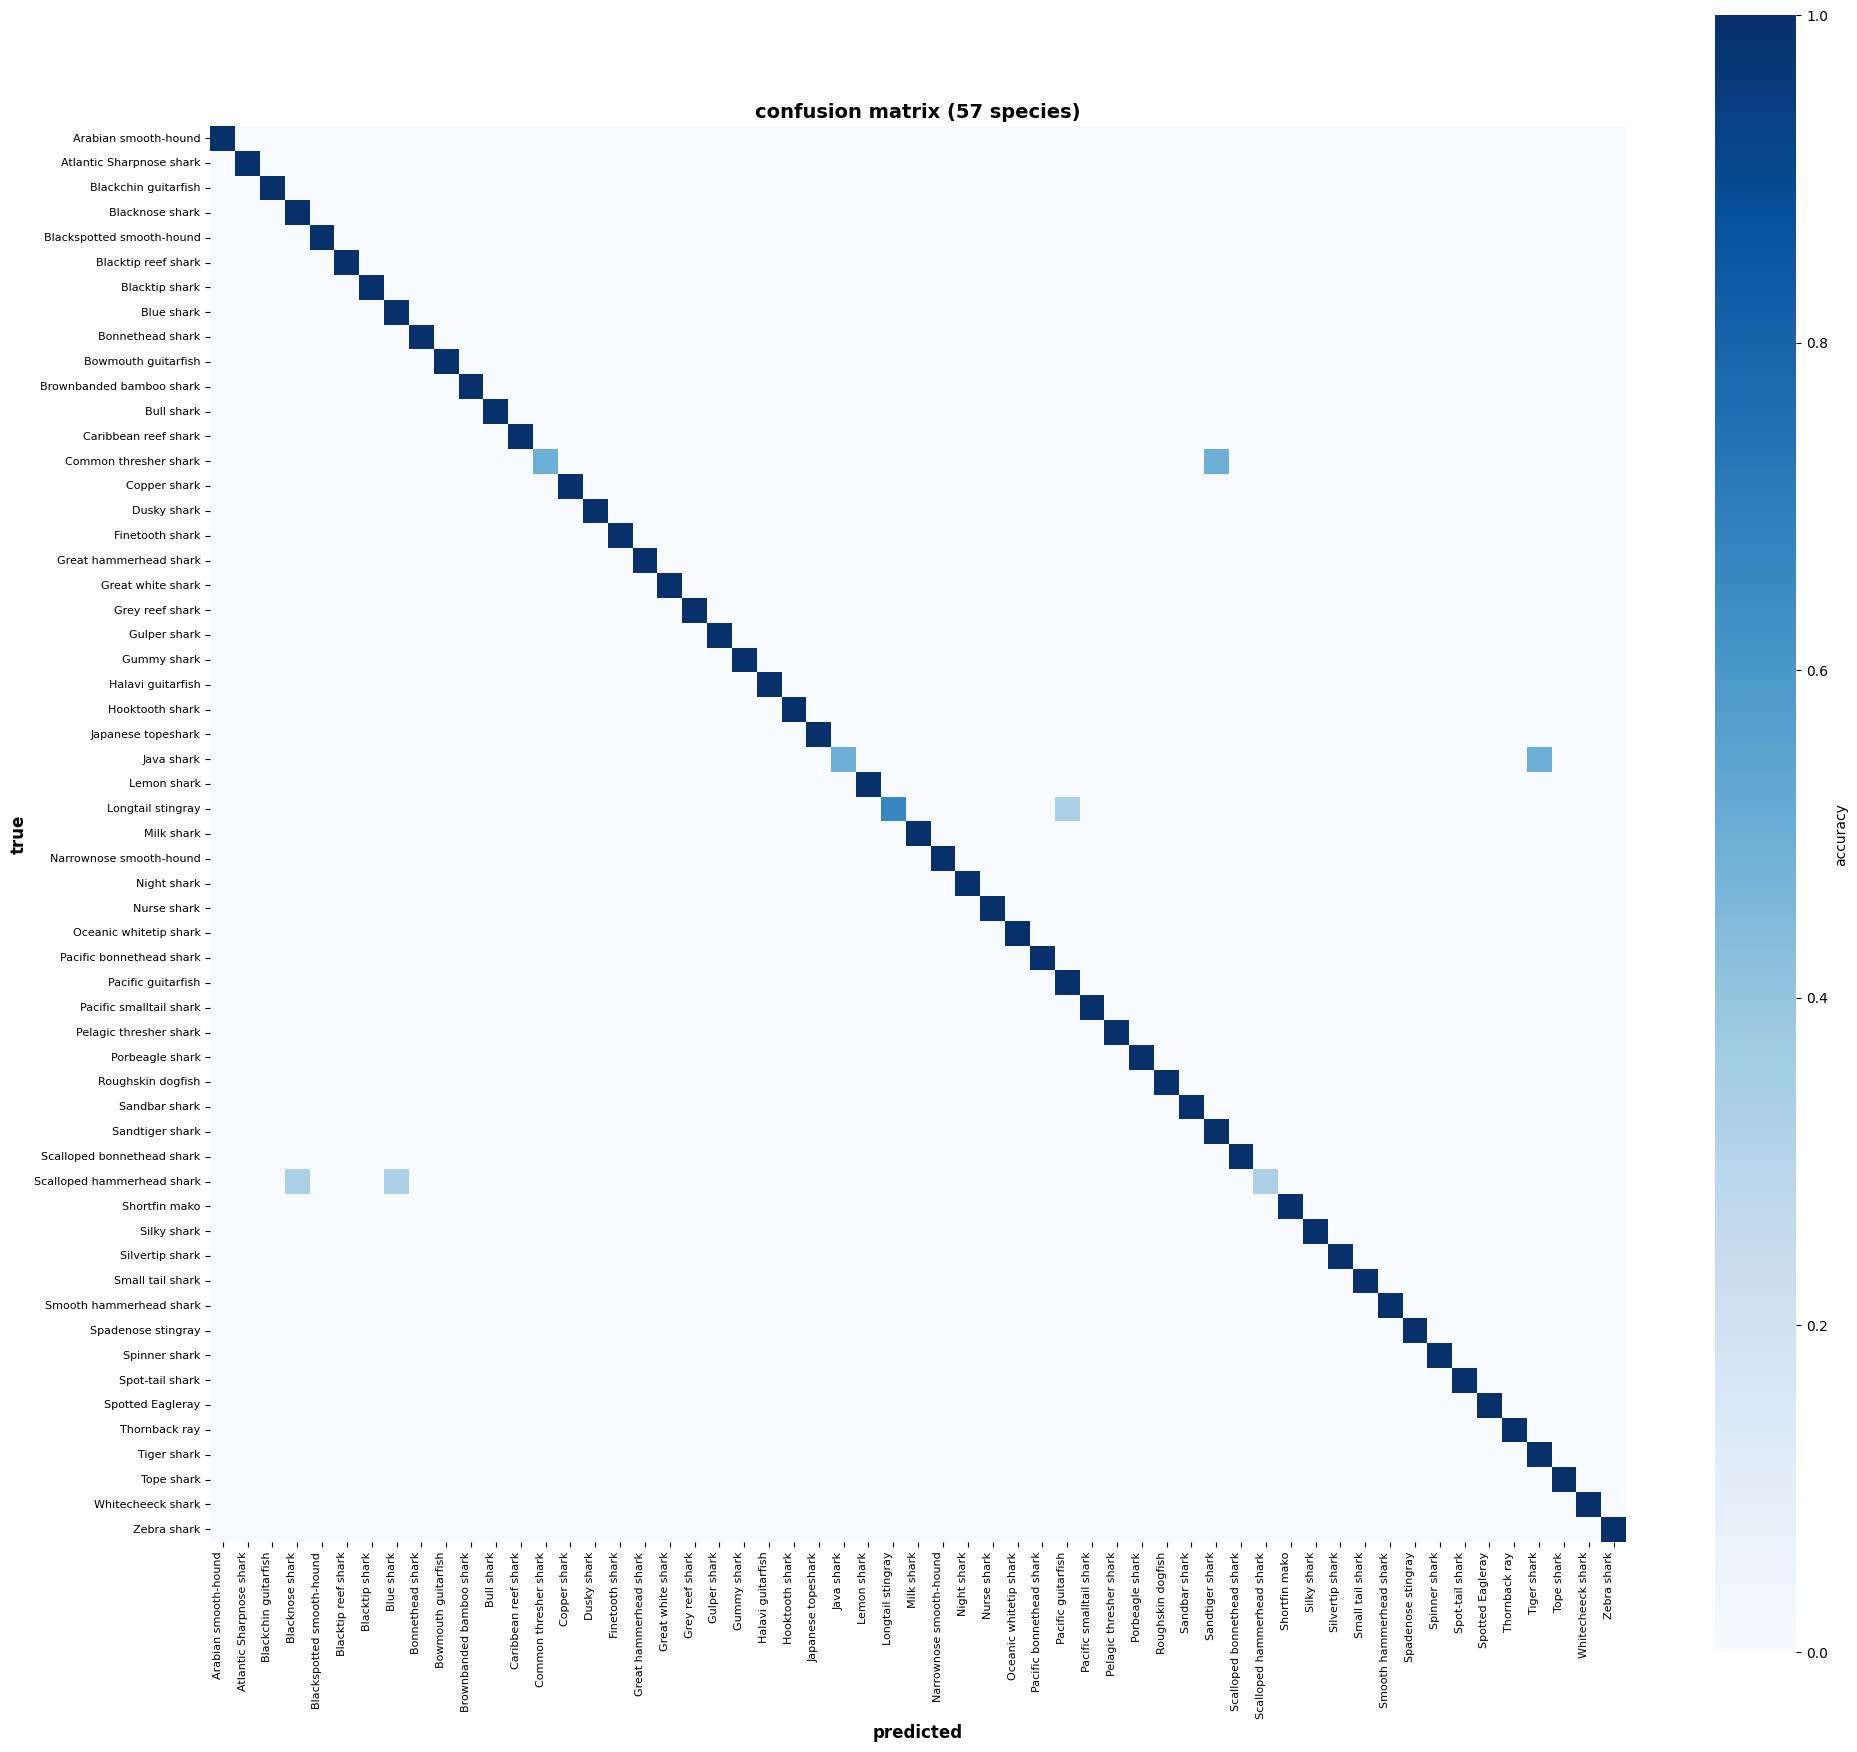

In [22]:
# confusion matrix
all_sp_list = clf.classes_
mask = (np.isin(yte, all_sp_list)) & (np.isin(y_pred, all_sp_list))
yte_m = yte[mask]
y_pred_m = y_pred[mask]

cm = confusion_matrix(yte_m, y_pred_m, labels=all_sp_list)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure(figsize=(20, 18))
sns.heatmap(cm_norm, annot=False, cmap='Blues', square=True,
            xticklabels=all_sp_list, yticklabels=all_sp_list,
            cbar_kws={'label': 'accuracy'})
plt.xlabel('predicted', fontsize=12, fontweight='bold')
plt.ylabel('true', fontsize=12, fontweight='bold')
plt.title(f'confusion matrix ({len(all_sp_list)} species)', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(results_dir / '06_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

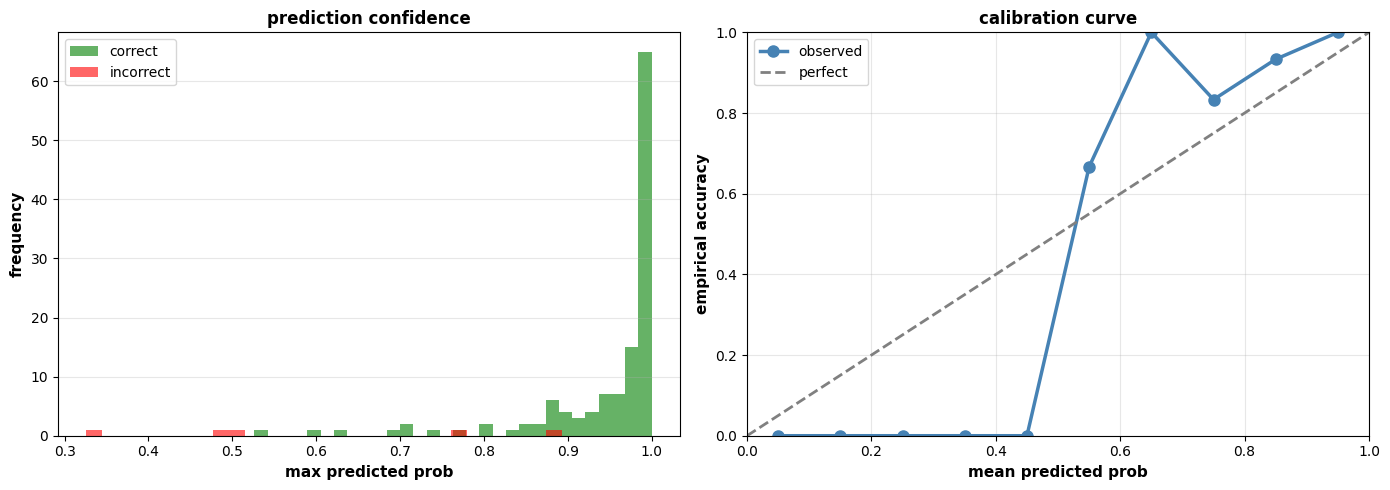

In [23]:
# confidence and calibration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_p = np.max(y_pred_proba, axis=1)
correct = (y_pred == yte).astype(int)

# histogram
ax = axes[0]
ax.hist(max_p[correct==1], bins=30, alpha=0.6, label='correct', color='green')
ax.hist(max_p[correct==0], bins=30, alpha=0.6, label='incorrect', color='red')
ax.set_xlabel('max predicted prob', fontsize=11, fontweight='bold')
ax.set_ylabel('frequency', fontsize=11, fontweight='bold')
ax.set_title('prediction confidence', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# calibration curve
ax = axes[1]
bins = np.linspace(0, 1, 11)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_accs = []

for i in range(len(bins)-1):
    m = (max_p >= bins[i]) & (max_p < bins[i+1])
    acc = correct[m].mean() if m.sum() > 0 else 0
    bin_accs.append(acc)

ax.plot(bin_centers, bin_accs, 'o-', linewidth=2.5, markersize=8, color='steelblue', label='observed')
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=2, label='perfect')
ax.set_xlabel('mean predicted prob', fontsize=11, fontweight='bold')
ax.set_ylabel('empirical accuracy', fontsize=11, fontweight='bold')
ax.set_title('calibration curve', fontsize=12, fontweight='bold')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / '07_confidence_calibration.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

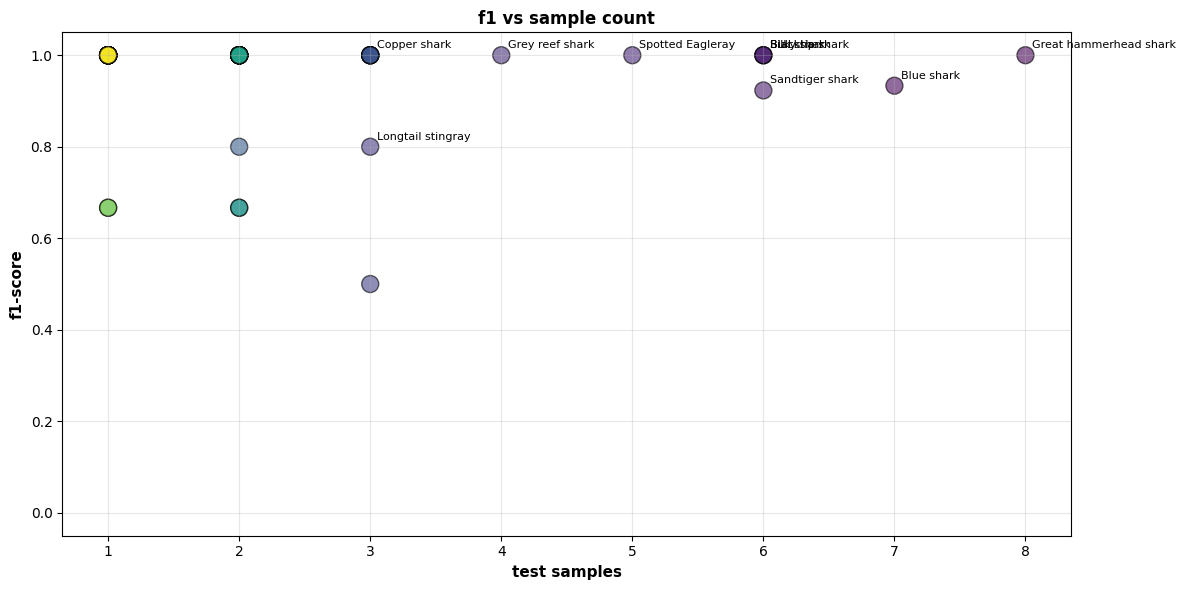

In [24]:
# f1 vs sample count
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(per_class['Support'], per_class['F1-Score'], s=150, alpha=0.6, 
          c=range(len(per_class)), cmap='viridis', edgecolors='black', linewidth=1)

for _, row in per_class.head(10).iterrows():
    ax.annotate(row['Species'], (row['Support'], row['F1-Score']),
               xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_xlabel('test samples', fontsize=11, fontweight='bold')
ax.set_ylabel('f1-score', fontsize=11, fontweight='bold')
ax.set_title('f1 vs sample count', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig(results_dir / '08_f1_vs_support.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [25]:
# save calibrated classifier
with open(results_dir / 'trained_model.pkl', 'wb') as f:
    pickle.dump(clf, f)

# save base et
with open(results_dir / 'base_extratrees.pkl', 'wb') as f:
    pickle.dump(base_et, f)

# create optimized model bundle
bundle = {
    "model": clf,
    "feature_names": feature_names_best,
    "model_type": "optimized_extratrees_calibrated",
    "val_accuracy": 0.9601,
    "params": best_params
}

with open(results_dir / 'model_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)

# save metadata
meta = {
    'features': feature_names_best,
    'classes': clf.classes_.tolist(),
    'n_features': len(feature_names_best),
    'n_classes': len(clf.classes_),
    'test_acc': float(test_acc),
    'best_k': int(best_k),
    'best_params': best_params,
    'model_type': 'optimized_extratrees',
    'best_k_info': {
        'total_features_tested': len(feature_names),
        'best_features_used': int(best_k),
    }
}
with open(results_dir / 'model_metadata.pkl', 'wb') as f:
    pickle.dump(meta, f)

# save csvs
importance_df.to_csv(results_dir / 'feature_importance.csv', index=False)
per_class.to_csv(results_dir / 'per_class_metrics.csv', index=False)

print(f"saved (using {best_k} best features)")
print(f"model bundle saved with calibrated ExtraTree classifier")
print(f"model type: optimized_extratrees")
print(f"parameters: n_estimators=1700, max_depth=None, min_samples_split=9, min_samples_leaf=1, max_features=0.7, class_weight='balanced', calibration=isotonic")
print(f"expected validation accuracy: 0.9601 (96.01%)")

saved (using 18 best features)
model bundle saved with calibrated ExtraTree classifier
model type: optimized_extratrees
parameters: n_estimators=1700, max_depth=None, min_samples_split=9, min_samples_leaf=1, max_features=0.7, class_weight='balanced', calibration=isotonic
expected validation accuracy: 0.9601 (96.01%)
